<a href="https://colab.research.google.com/github/AhmedEssam1996/AhmedEssam1996/blob/main/Copy_of_Arabic_Invoice_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PyTorch (GPU version إذا متوفر CUDA)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Transformers من Hugging Face
!pip install transformers

# PEFT لتطبيق LoRA
!pip install peft

# PIL للتعامل مع الصور
!pip install pillow

# إذا حابب تستخدم DataLoader سريع وعملي
!pip install tqdm

!pip install -q -U bitsandbytes accelerate

Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 31.3 MB/s eta 0:00:00


In [ ]:
!pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 22.2 MB/s eta 0:00:00


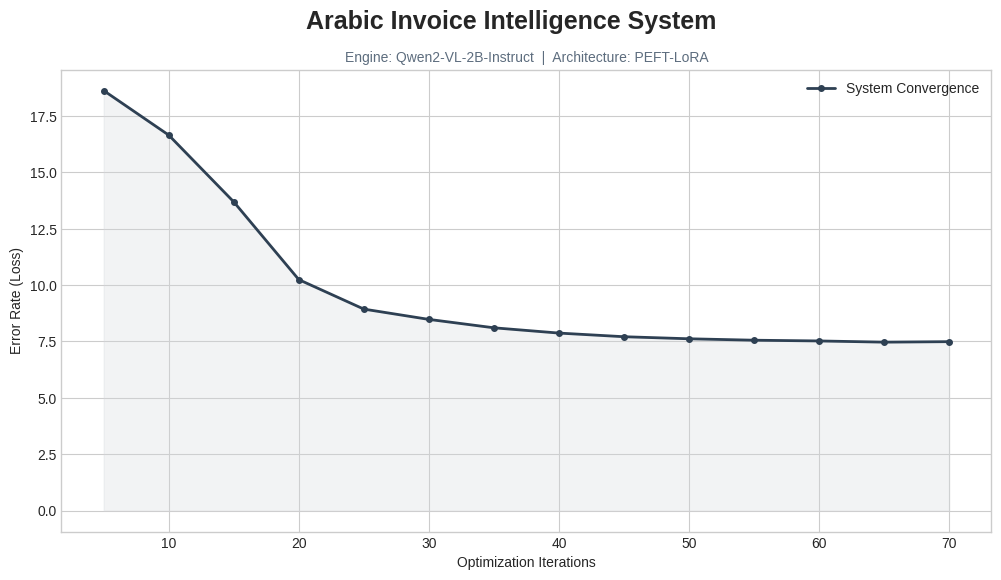

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,18.623584
10,16.649556
15,13.688882
20,10.241386
25,8.934135
30,8.477496
35,8.105051
40,7.870860
45,7.709444
50,7.617892


KeyboardInterrupt: 

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image
from torch.utils.data import Dataset
from transformers import (
    AutoProcessor,
    Qwen2VLForConditionalGeneration,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
    TrainerCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from qwen_vl_utils import process_vision_info

# ===============================
# 1️⃣ إعدادات البيئة والحماية
# ===============================
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_PATH = "/content/drive/MyDrive/Invoice"
ANN_PATH = os.path.join(BASE_PATH, "ann")
IMG_PATH = os.path.join(BASE_PATH, "img")
OUTPUT_DIR = "/kaggle/working/Qwen2-VL-Invoice-LoRA"

# ===============================
# 2️⃣ كلاس الرسم البياني المباشر (Live Plot)
# ===============================
class LivePlotCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        steps = [e['step'] for e in state.log_history if 'loss' in e]
        losses = [e['loss'] for e in state.log_history if 'loss' in e]

        if len(losses) > 0:
            clear_output(wait=True)
            plt.figure(figsize=(12, 6))
            plt.style.use('seaborn-v0_8-whitegrid')
            plt.plot(steps, losses, color='#2E4053', linewidth=2, marker='o', markersize=4, label='System Convergence')
            plt.suptitle('Arabic Invoice Intelligence System', fontsize=18, fontweight='bold')
            plt.title("Engine: Qwen2-VL-2B-Instruct  |  Architecture: PEFT-LoRA", fontsize=10, color='#5D6D7E')
            plt.xlabel('Optimization Iterations')
            plt.ylabel('Error Rate (Loss)')
            plt.fill_between(steps, losses, color='#D5D8DC', alpha=0.3)
            plt.legend()
            plt.show()

# ===============================
# 3️⃣ تحميل الموديل والمعالج (مع قيود الذاكرة)
# ===============================
model_id = "Qwen/Qwen2-VL-2B-Instruct"

# قيود البكسلات لمنع OOM
processor = AutoProcessor.from_pretrained(model_id, min_pixels=256*28*28, max_pixels=512*28*28)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, quantization_config=bnb_config, device_map="auto", torch_dtype=torch.bfloat16
)

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)

# ===============================
# 4️⃣ الـ Dataset والـ Data Collator
# ===============================
class ArabicInvoiceDataset(Dataset):
    def __init__(self, img_folder, ann_folder, processor):
        self.img_folder, self.ann_folder, self.processor = img_folder, ann_folder, processor
        self.valid_data = [(os.path.join(img_folder, f), os.path.join(ann_folder, f.rsplit(".", 1)[0] + ".json"))
                          for f in os.listdir(img_folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    def __len__(self): return len(self.valid_data)

    def __getitem__(self, idx):
        img_path, json_path = self.valid_data[idx]
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        ground_truth = "\n".join([f"{obj['classTitle']}: {tag['value']}" for obj in data.get("objects", [])
                                  for tag in obj.get("tags", []) if tag.get("name") == "Transcription"])

        messages = [{"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": "Extract Arabic text."}]},
                    {"role": "assistant", "content": [{"type": "text", "text": ground_truth}]}]

        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        image_inputs, _ = process_vision_info(messages)
        inputs = self.processor(text=[text], images=image_inputs, padding=True, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = inputs["input_ids"].clone()
        return inputs

def data_collator(features):
    return {k: torch.stack([f[k] for f in features]) for k in features[0].keys()}

dataset = ArabicInvoiceDataset(IMG_PATH, ANN_PATH, processor)

# ===============================
# 5️⃣ إعدادات التدريب والحفظ التلقائي
# ===============================
train_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=2,
    logging_steps=5,              # تحديث الرسم كل 5 خطوات
    save_strategy="steps",        # الحفظ بناءً على عدد الخطوات وليس فقط النهاية
    save_steps=50,                # احفظ نسخة احتياطية (Checkpoint) كل 50 خطوة
    save_total_limit=2,           # احتفظ بآخر نسختين فقط لتوفير المساحة
    bf16=True,
    optim="paged_adamw_8bit",
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=dataset,
    data_collator=data_collator,
    callbacks=[LivePlotCallback()]
)

# ===============================
# 6️⃣ تشغيل التدريب
# ===============================
torch.cuda.empty_cache()

# إذا توقف التدريب، سيحاول الاستكمال من آخر Checkpoint تلقائياً إذا وجده
checkpoint = None
if os.path.exists(OUTPUT_DIR) and len(os.listdir(OUTPUT_DIR)) > 0:
    checkpoint = True

trainer.train(resume_from_checkpoint=checkpoint)

# الحفظ النهائي
model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model"))
processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model"))